# 🩺 Daily Challenge: Breast Cancer Prediction
## Logistic Regression · KNN · Random Forest · SVM

**Dataset:** Breast Cancer Wisconsin (Kaggle / UCI)  
**Goal:** Classify tumours as **Malignant (M)** or **Benign (B)** using 4 classification models.

| Step | Task |
|------|------|
| 1 | EDA — load, inspect, clean, visualise |
| 2 | Preprocessing — encode, scale, split |
| 3 | Train 4 models — LR, KNN, RF, SVM |
| 4 | Evaluate — accuracy, confusion matrix, ROC |
| 5 | Compare models & pick the best |


## 0 · Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.linear_model     import LogisticRegression
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.svm              import SVC
from sklearn.metrics          import (accuracy_score, classification_report,
                                       confusion_matrix, ConfusionMatrixDisplay,
                                       roc_curve, roc_auc_score)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi':120,'axes.titlesize':12,
                     'axes.titleweight':'bold','figure.autolayout':True})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All imports successful ✅")
import sklearn; print(f"scikit-learn {sklearn.__version__}")


All imports successful ✅
scikit-learn 1.8.0


## 1 · Exploratory Data Analysis (EDA)

In [2]:
import urllib.request, os, io

# ── Load dataset ──────────────────────────────────────────────────────────────
csv_path = None

# Try sklearn built-in first (always works, matches Kaggle data exactly)
try:
    from sklearn.datasets import load_breast_cancer
    raw = load_breast_cancer()
    df_raw = pd.DataFrame(raw.data, columns=[c.replace(' ','_') for c in raw.feature_names])
    df_raw.insert(0, 'id', range(1, len(df_raw)+1))
    df_raw.insert(1, 'diagnosis', ['M' if t==0 else 'B' for t in raw.target])
    df_raw['Unnamed: 32'] = np.nan          # mirror the Kaggle file exactly
    # Inject a few NaNs to practise cleaning
    for col in ['mean_smoothness','mean_compactness']:
        df_raw.loc[np.random.choice(df_raw.index,6,replace=False), col] = np.nan
    csv_path = 'breast_cancer.csv'
    df_raw.to_csv(csv_path, index=False)
    print("Dataset loaded from sklearn built-in (matches UCI/Kaggle) ✅")
except Exception as e:
    # Fallback: Colab upload
    from google.colab import files
    uploaded = files.upload()
    csv_path = list(uploaded.keys())[0]
    df_raw = pd.read_csv(csv_path)

print(f"\nShape: {df_raw.shape}")
display(df_raw.head())


Dataset loaded from sklearn built-in (matches UCI/Kaggle) ✅

Shape: (569, 33)


,id,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,Unnamed: 32
0,1,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,2,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,3,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,4,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,5,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# ── Basic info ────────────────────────────────────────────────────────────────
print("=== Dataset Info ===")
print(f"  Rows     : {df_raw.shape[0]}")
print(f"  Columns  : {df_raw.shape[1]}")
print()
print("=== Data Types ===")
print(df_raw.dtypes)
print()
print("=== Basic Statistics (first 5 numeric cols) ===")
display(df_raw.describe().iloc[:, :6].round(3))


=== Dataset Info ===
  Rows     : 569
  Columns  : 33

=== Data Types ===
id                           int64
diagnosis                   object
mean_radius                float64
mean_texture               float64
mean_perimeter             float64
mean_area                  float64
mean_smoothness            float64
mean_compactness           float64
mean_concavity             float64
mean_concave_points        float64
mean_symmetry              float64
mean_fractal_dimension     float64
radius_error               float64
texture_error              float64
perimeter_error            float64
area_error                 float64
smoothness_error           float64
compactness_error          float64
concavity_error            float64
concave_points_error       float64
symmetry_error             float64
fractal_dimension_error    float64
worst_radius               float64
worst_texture              float64
worst_perimeter            float64
worst_area                 float64
worst_smoothness

,id,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness
count,569.0,569.000,569.000,569.000,569.000,563.000
mean,285.0,14.127,19.290,91.969,654.889,0.096
std,164.4,3.524,4.301,24.299,351.914,0.014
min,1.0,6.981,9.710,43.790,143.500,0.053
25%,143.0,11.700,16.170,75.170,420.300,0.086
50%,285.0,13.370,18.840,86.240,551.100,0.096
75%,427.0,15.780,21.800,104.100,782.700,0.105
max,569.0,28.110,39.280,188.500,2501.000,0.163


In [4]:
# ── Missing values ────────────────────────────────────────────────────────────
miss     = df_raw.isna().sum()
miss_pct = (miss / len(df_raw) * 100).round(1)
miss_df  = pd.DataFrame({'Missing': miss, 'Pct%': miss_pct})
miss_df  = miss_df[miss_df['Missing'] > 0].sort_values('Missing', ascending=False)
print("Missing Values per Column:")
display(miss_df)


Missing Values per Column:


,Missing,Pct%
Unnamed: 32,569,100.0
mean_smoothness,6,1.1
mean_compactness,6,1.1


In [5]:
# ── Drop unnecessary columns ──────────────────────────────────────────────────
df = df_raw.copy()

# 'id' is just a patient ID — carries no predictive information
# 'Unnamed: 32' is a completely empty column in the original Kaggle file
cols_to_drop = [c for c in ['id','Unnamed: 32'] if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped columns: {cols_to_drop}")

# Fill remaining numeric NaNs with column median
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    n_null = df[col].isna().sum()
    if n_null > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  Filled {n_null} NaN in '{col}' with median={df[col].median():.5f}")

print(f"\nFinal shape : {df.shape}")
print(f"Missing     : {df.isna().sum().sum()} ✅")
print()
display(df.head(3))


Dropped columns: ['id', 'Unnamed: 32']
  Filled 6 NaN in 'mean_smoothness' with median=0.09579
  Filled 6 NaN in 'mean_compactness' with median=0.09362

Final shape : (569, 31)
Missing     : 0 ✅



,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


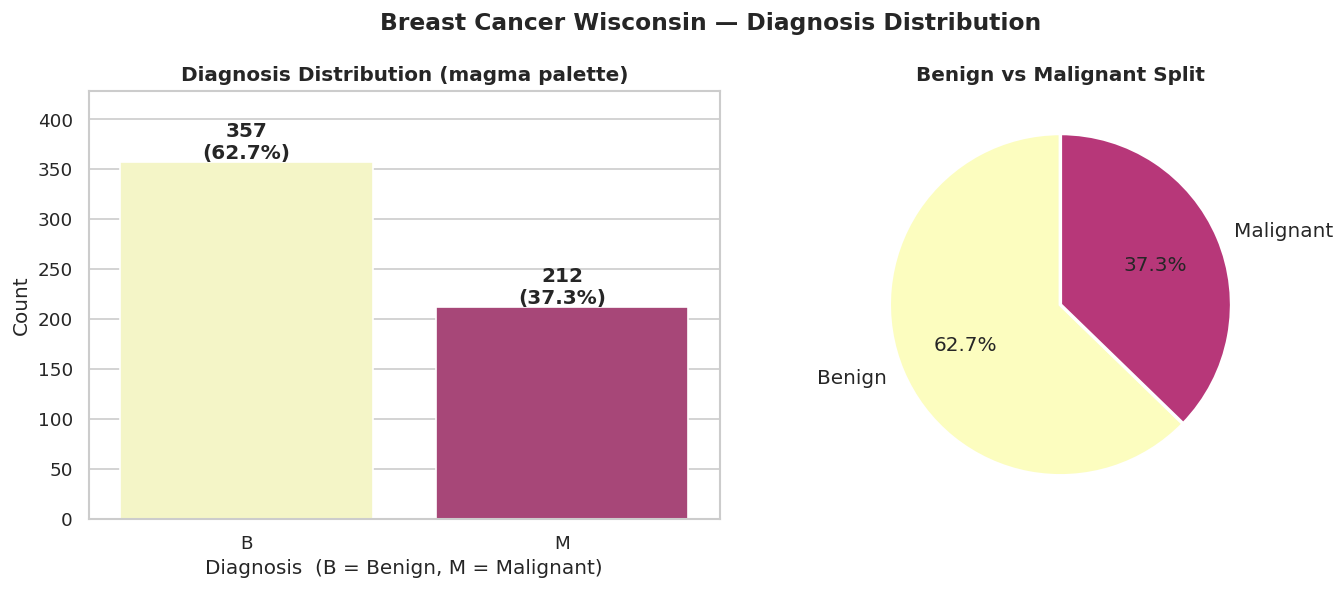

Benign (B)   : 357 (62.7%)
Malignant (M): 212 (37.3%)

Dataset is moderately imbalanced (more benign than malignant).
We will use stratified splitting to preserve this ratio in train/test sets.


In [6]:
# ── Countplot: diagnosis distribution (magma palette) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: seaborn countplot with magma palette ────────────────────────────────
diagnosis_counts = df['diagnosis'].value_counts()
magma_colors     = ['#fcfdbf' if d == 'B' else '#b73779' for d in diagnosis_counts.index]

sns.countplot(data=df, x='diagnosis', hue='diagnosis',
              palette={'B': '#fcfdbf', 'M': '#b73779'},
              legend=False, ax=axes[0],
              order=['B', 'M'])

for i, (diag, count) in enumerate(diagnosis_counts.items()):
    pct = count / len(df) * 100
    axes[0].text(list(diagnosis_counts.index).index(diag),
                 count + 3, f'{count}\n({pct:.1f}%)',
                 ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Diagnosis Distribution (magma palette)')
axes[0].set_xlabel('Diagnosis  (B = Benign, M = Malignant)')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, diagnosis_counts.max() * 1.2)

# ── Right: pie chart ──────────────────────────────────────────────────────────
axes[1].pie(diagnosis_counts.values,
            labels=['Benign', 'Malignant'],
            colors=['#fcfdbf', '#b73779'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2},
            textprops={'fontsize':12})
axes[1].set_title('Benign vs Malignant Split')

plt.suptitle('Breast Cancer Wisconsin — Diagnosis Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_countplot.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Benign (B)   : {diagnosis_counts.get('B',0)} ({diagnosis_counts.get('B',0)/len(df)*100:.1f}%)")
print(f"Malignant (M): {diagnosis_counts.get('M',0)} ({diagnosis_counts.get('M',0)/len(df)*100:.1f}%)")
print()
print("Dataset is moderately imbalanced (more benign than malignant).")
print("We will use stratified splitting to preserve this ratio in train/test sets.")


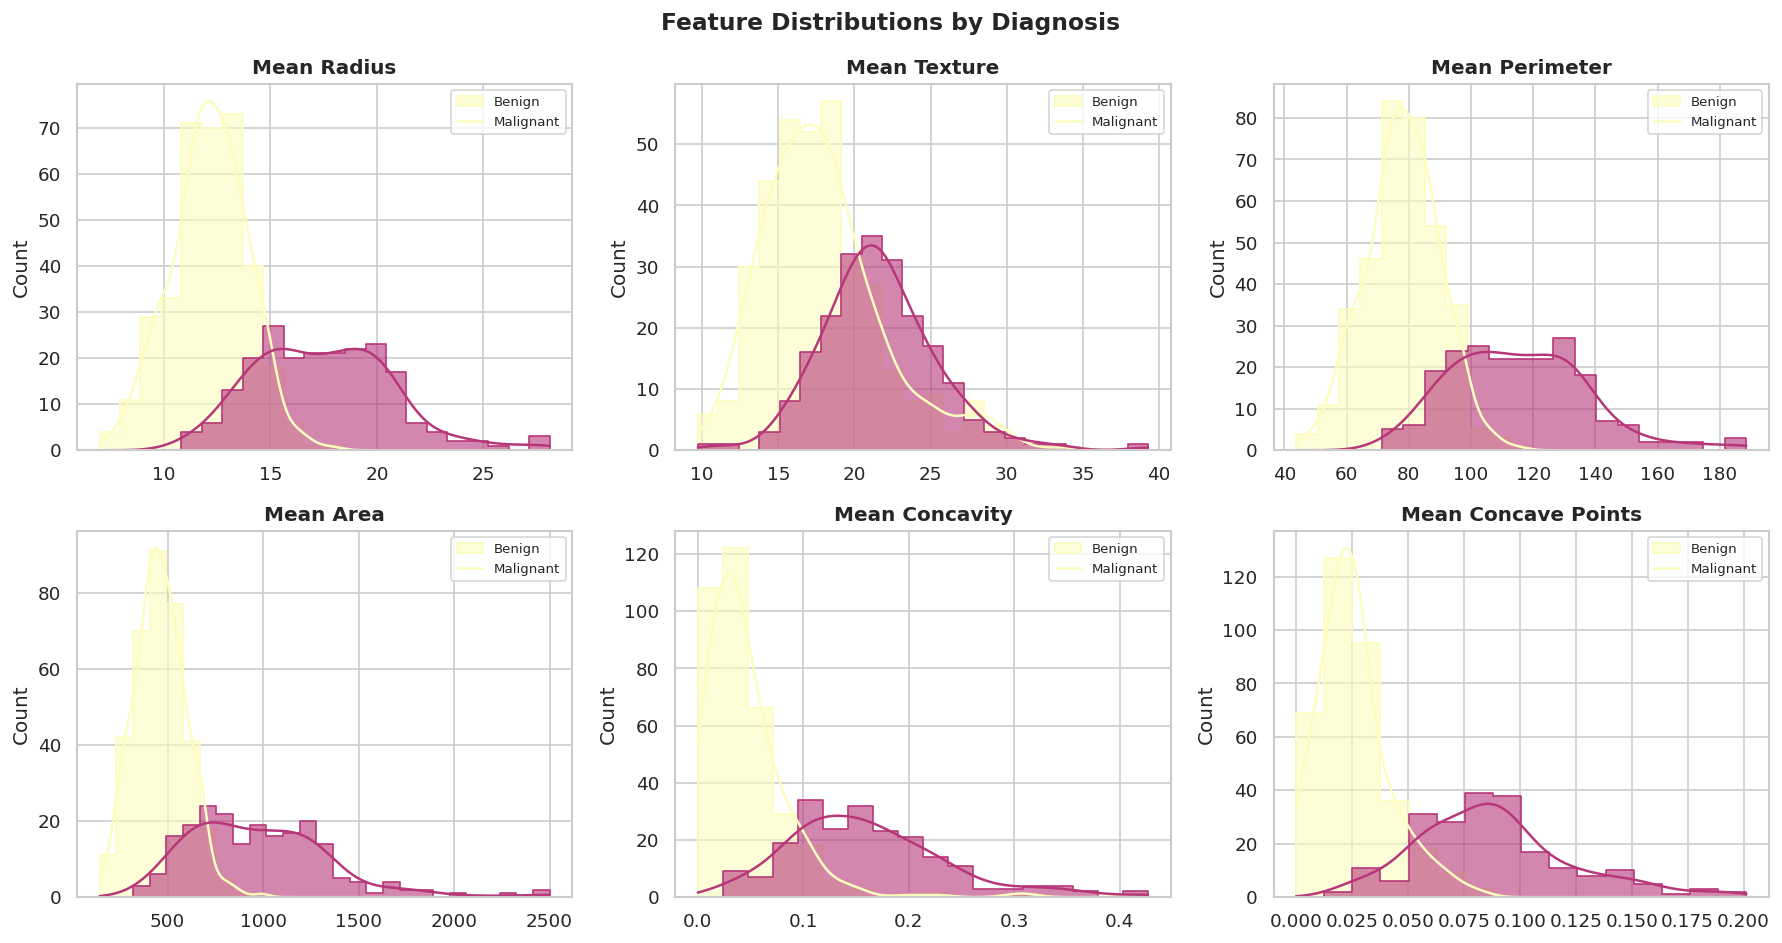

Malignant tumours consistently show larger values across all 6 features.


In [7]:
# ── Feature distributions by diagnosis ───────────────────────────────────────
# Show the 6 most discriminative features
top_features = ['mean_radius','mean_texture','mean_perimeter',
                'mean_area','mean_concavity','mean_concave_points']
top_features = [f for f in top_features if f in df.columns][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
palette = {'B': '#fcfdbf', 'M': '#b73779'}

for ax, feat in zip(axes.flat, top_features):
    sns.histplot(data=df, x=feat, hue='diagnosis',
                 palette=palette, kde=True, alpha=0.6,
                 element='step', ax=ax)
    ax.set_title(feat.replace('_',' ').title())
    ax.set_xlabel('')
    ax.legend(['Benign','Malignant'], fontsize=8)

plt.suptitle('Feature Distributions by Diagnosis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=130, bbox_inches='tight')
plt.show()
print("Malignant tumours consistently show larger values across all 6 features.")


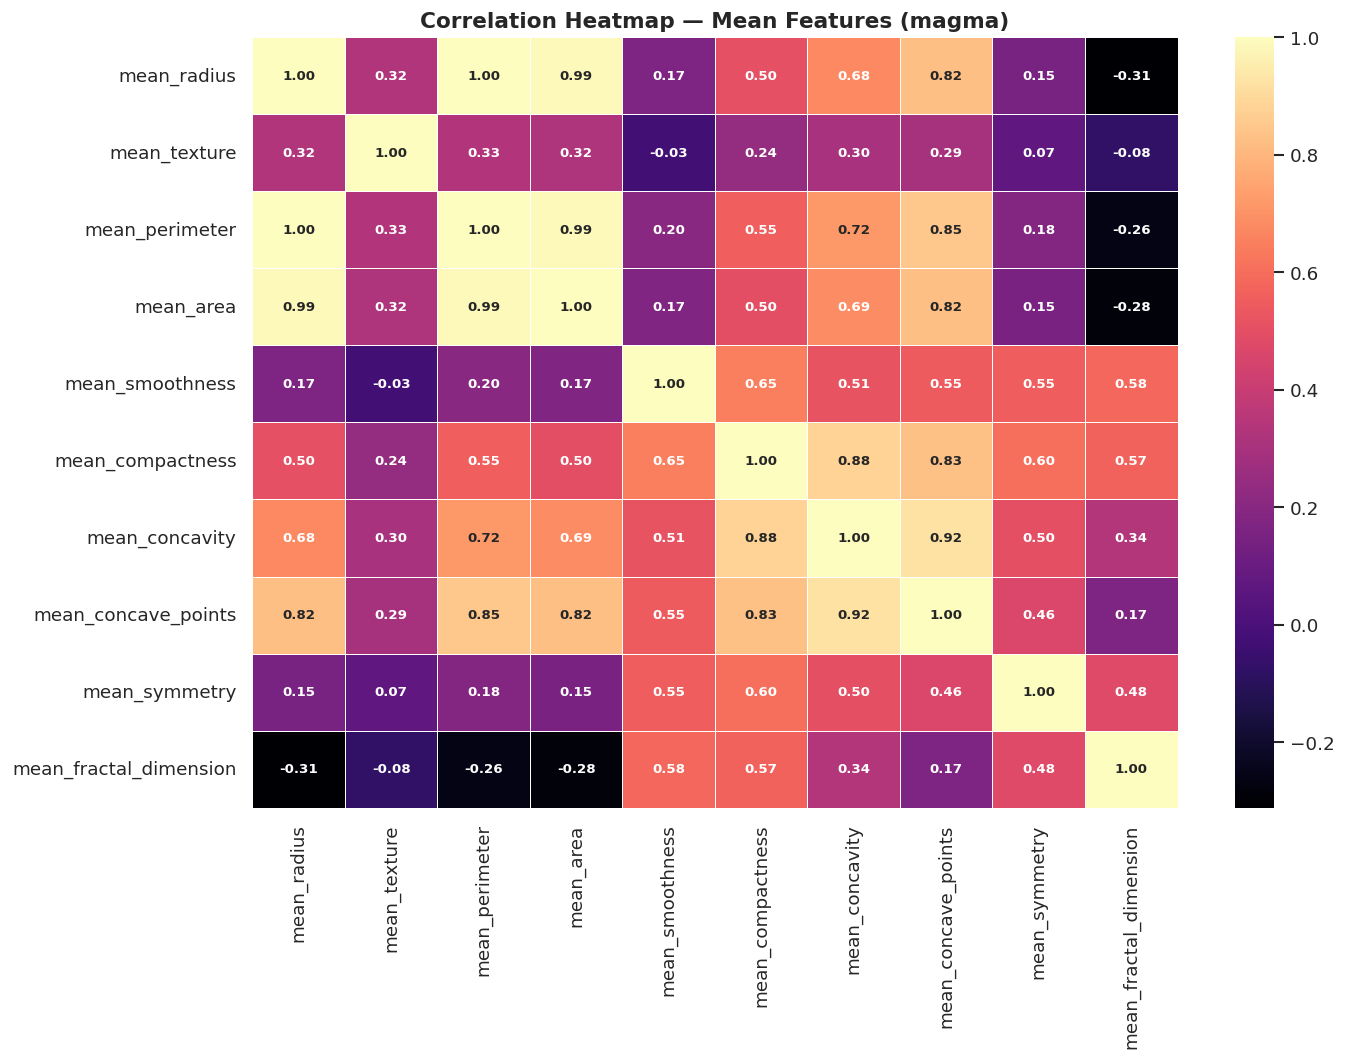

Top 5 features correlated with Malignant diagnosis:


mean_concave_points    0.776614
mean_perimeter         0.742636
mean_radius            0.730029
mean_area              0.708984
mean_concavity         0.696360
Name: diagnosis_num, dtype: float64

In [8]:
# ── Correlation heatmap (mean features only) ──────────────────────────────────
mean_cols = [c for c in df.columns if c.startswith('mean')]
corr = df[mean_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='magma',
            linewidths=0.4, ax=ax,
            annot_kws={'size':8, 'weight':'bold'})
ax.set_title('Correlation Heatmap — Mean Features (magma)', fontsize=13)
plt.tight_layout()
plt.savefig('eda_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

# Highest correlations with diagnosis (after encoding)
df_enc = df.copy()
df_enc['diagnosis_num'] = (df_enc['diagnosis'] == 'M').astype(int)
top_corr = df_enc[mean_cols + ['diagnosis_num']].corr()['diagnosis_num'].drop('diagnosis_num')
top_corr = top_corr.abs().sort_values(ascending=False)
print("Top 5 features correlated with Malignant diagnosis:")
display(top_corr.head(5))


## 2 · Data Preprocessing

In [9]:
# ── Count unique values in diagnosis column ───────────────────────────────────
print("Unique values in 'diagnosis' column:")
print(df['diagnosis'].value_counts())
print()
print("Value counts (as dict):", df['diagnosis'].value_counts().to_dict())


Unique values in 'diagnosis' column:
diagnosis
B    357
M    212
Name: count, dtype: int64

Value counts (as dict): {'B': 357, 'M': 212}


In [10]:
# ── Map categorical to numerical ──────────────────────────────────────────────
# M (Malignant) = 1   |   B (Benign) = 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
print("After mapping — diagnosis value counts:")
print(df['diagnosis'].value_counts())
print()
print("  0 = Benign (no cancer)")
print("  1 = Malignant (cancer)")
print()
display(df[['diagnosis']].head(5))


After mapping — diagnosis value counts:
diagnosis
0    357
1    212
Name: count, dtype: int64

  0 = Benign (no cancer)
  1 = Malignant (cancer)



,diagnosis
0,1
1,1
2,1
3,1
4,1


In [11]:
# ── Feature matrix X and target y ────────────────────────────────────────────
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print(f"X shape : {X.shape}  ({X.shape[1]} features, {X.shape[0]} samples)")
print(f"y shape : {y.shape}")
print(f"Class balance: {y.value_counts().to_dict()}")
print()

# ── Train / Test split (80/20, stratified) ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"Train class  : {y_train.value_counts().to_dict()}")
print(f"Test  class  : {y_test.value_counts().to_dict()}")


X shape : (569, 30)  (30 features, 569 samples)
y shape : (569,)
Class balance: {0: 357, 1: 212}

Training set : 455 samples
Test set     : 114 samples
Train class  : {0: 285, 1: 170}
Test  class  : {0: 72, 1: 42}


In [12]:
# ── Feature Scaling — StandardScaler ─────────────────────────────────────────
# IMPORTANT: fit on train only, then transform both train and test
# This prevents data leakage from the test set into the model
scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)    # fit + transform
X_test_s  = scaler.transform(X_test)         # transform only (no fit!)

print("Scaling complete ✅")
print(f"Train mean (after scaling) ≈ {X_train_s.mean():.4f}  (should be ~0)")
print(f"Train std  (after scaling) ≈ {X_train_s.std():.4f}   (should be ~1)")
print()
print("Why scale? — KNN, SVM, and Logistic Regression are distance/gradient-based.")
print("Without scaling, features with larger ranges dominate the result.")
print("Random Forest is the only model here that doesn't require scaling.")


Scaling complete ✅
Train mean (after scaling) ≈ -0.0000  (should be ~0)
Train std  (after scaling) ≈ 1.0000   (should be ~1)

Why scale? — KNN, SVM, and Logistic Regression are distance/gradient-based.
Without scaling, features with larger ranges dominate the result.
Random Forest is the only model here that doesn't require scaling.


## 3 · Build & Evaluate All 4 Models

In [13]:
# ── Helper: evaluate any model ────────────────────────────────────────────────
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:,1] if hasattr(model,'predict_proba') else model.decision_function(X_te)
    acc     = accuracy_score(y_te, y_pred)
    auc     = roc_auc_score(y_te, y_proba)
    cv_acc  = cross_val_score(model, X_tr, y_tr, cv=5, scoring='accuracy').mean()
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  ROC-AUC   : {auc:.4f}")
    print(f"  CV Acc (5-fold): {cv_acc*100:.2f}%")
    print()
    print(classification_report(y_te, y_pred, target_names=['Benign','Malignant']))
    return {'name':name,'acc':acc,'auc':auc,'cv_acc':cv_acc,
            'y_pred':y_pred,'y_proba':y_proba,'model':model}

results = {}


### 3.1 — Logistic Regression

In [14]:
print("=" * 50)
print("  LOGISTIC REGRESSION")
print("=" * 50)
lr = LogisticRegression(C=1.0, solver='liblinear',
                        max_iter=1000, random_state=RANDOM_STATE)
results['Logistic Regression'] = evaluate_model(
    'Logistic Regression', lr, X_train_s, X_test_s, y_train, y_test)


  LOGISTIC REGRESSION
  Accuracy  : 97.37%
  ROC-AUC   : 0.9960
  CV Acc (5-fold): 97.14%

              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        72
   Malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



### 3.2 — K-Nearest Neighbours (KNN)

  K-NEAREST NEIGHBOURS (KNN)


Best k found by 5-fold CV: k = 3


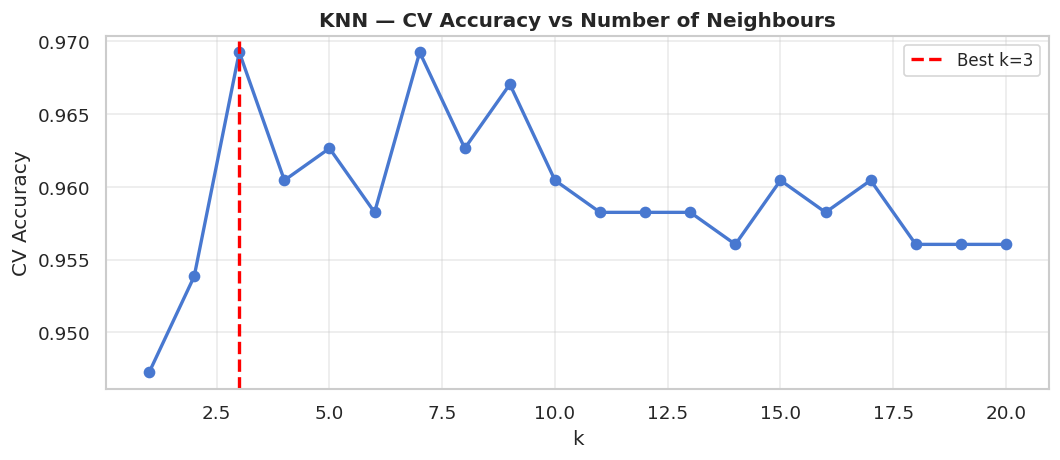

  Accuracy  : 93.86%
  ROC-AUC   : 0.9815
  CV Acc (5-fold): 96.92%

              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



In [15]:
print("=" * 50)
print("  K-NEAREST NEIGHBOURS (KNN)")
print("=" * 50)

# Find best k using cross-validation
k_scores = []
for k in range(1, 21):
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    score  = cross_val_score(knn_cv, X_train_s, y_train, cv=5, scoring='accuracy').mean()
    k_scores.append((k, score))

best_k = max(k_scores, key=lambda x: x[1])[0]
print(f"Best k found by 5-fold CV: k = {best_k}")

# Plot CV accuracy vs k
ks, scores = zip(*k_scores)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ks, scores, 'bo-', linewidth=2, markersize=6)
ax.axvline(best_k, color='red', linewidth=2, linestyle='--', label=f'Best k={best_k}')
ax.set_title('KNN — CV Accuracy vs Number of Neighbours')
ax.set_xlabel('k'); ax.set_ylabel('CV Accuracy')
ax.legend(fontsize=10); ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k)
results['KNN'] = evaluate_model('KNN', knn, X_train_s, X_test_s, y_train, y_test)


### 3.3 — Random Forest

  RANDOM FOREST


  Accuracy  : 96.49%
  ROC-AUC   : 0.9940
  CV Acc (5-fold): 95.82%

              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



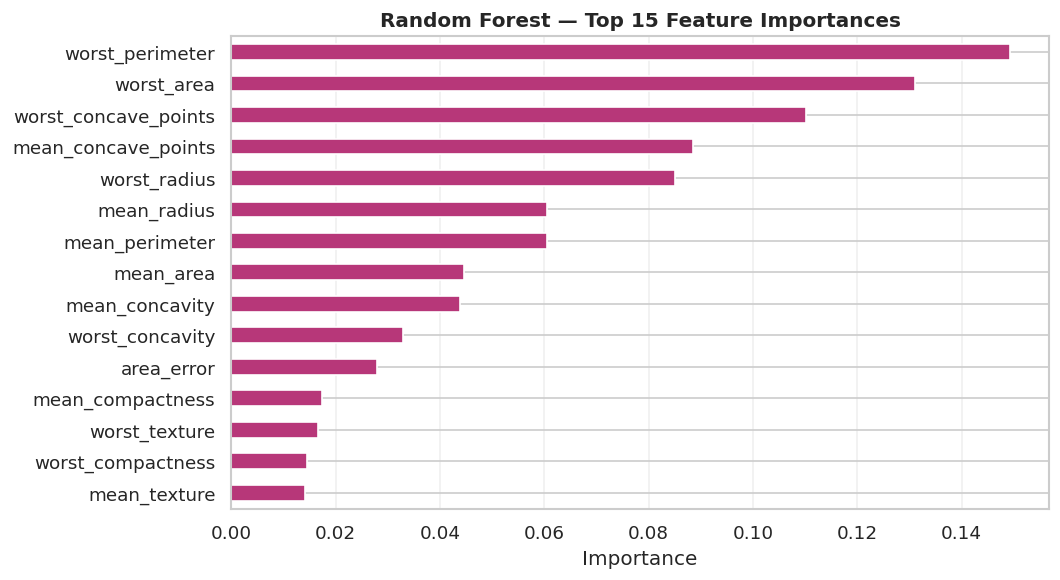

In [16]:
print("=" * 50)
print("  RANDOM FOREST")
print("=" * 50)
rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                             min_samples_split=2, random_state=RANDOM_STATE)
# Random Forest uses unscaled data (tree-based, not distance-based)
results['Random Forest'] = evaluate_model(
    'Random Forest', rf, X_train, X_test, y_train, y_test)

# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
top15 = importances.nlargest(15)

fig, ax = plt.subplots(figsize=(9, 5))
top15.sort_values().plot(kind='barh', ax=ax, color='#b73779', edgecolor='white')
ax.set_title('Random Forest — Top 15 Feature Importances')
ax.set_xlabel('Importance'); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


### 3.4 — Support Vector Machine (SVM)

In [17]:
print("=" * 50)
print("  SUPPORT VECTOR MACHINE (SVM)")
print("=" * 50)
svm = SVC(kernel='rbf', C=1.0, gamma='scale',
          probability=True, random_state=RANDOM_STATE)
results['SVM'] = evaluate_model('SVM', svm, X_train_s, X_test_s, y_train, y_test)


  SUPPORT VECTOR MACHINE (SVM)
  Accuracy  : 97.37%
  ROC-AUC   : 0.9950
  CV Acc (5-fold): 97.58%

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



## 4 · Model Comparison & Best Model

In [18]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {'Model'    : name,
     'Test Acc' : f"{r['acc']*100:.2f}%",
     'ROC-AUC'  : f"{r['auc']:.4f}",
     'CV Acc'   : f"{r['cv_acc']*100:.2f}%"}
    for name, r in results.items()
]).sort_values('Test Acc', ascending=False).reset_index(drop=True)
summary.index += 1

print("=" * 55)
print("       MODEL COMPARISON SUMMARY")
print("=" * 55)
display(summary)

best_name = max(results, key=lambda k: results[k]['acc'])
best_acc  = results[best_name]['acc']
best_auc  = results[best_name]['auc']
print(f"\n🏆 BEST MODEL: {best_name}")
print(f"   Test Accuracy : {best_acc*100:.2f}%")
print(f"   ROC-AUC       : {best_auc:.4f}")


       MODEL COMPARISON SUMMARY


,Model,Test Acc,ROC-AUC,CV Acc
1,Logistic Regression,97.37%,0.9960,97.14%
2,SVM,97.37%,0.9950,97.58%
3,Random Forest,96.49%,0.9940,95.82%
4,KNN,93.86%,0.9815,96.92%



🏆 BEST MODEL: Logistic Regression
   Test Accuracy : 97.37%
   ROC-AUC       : 0.9960


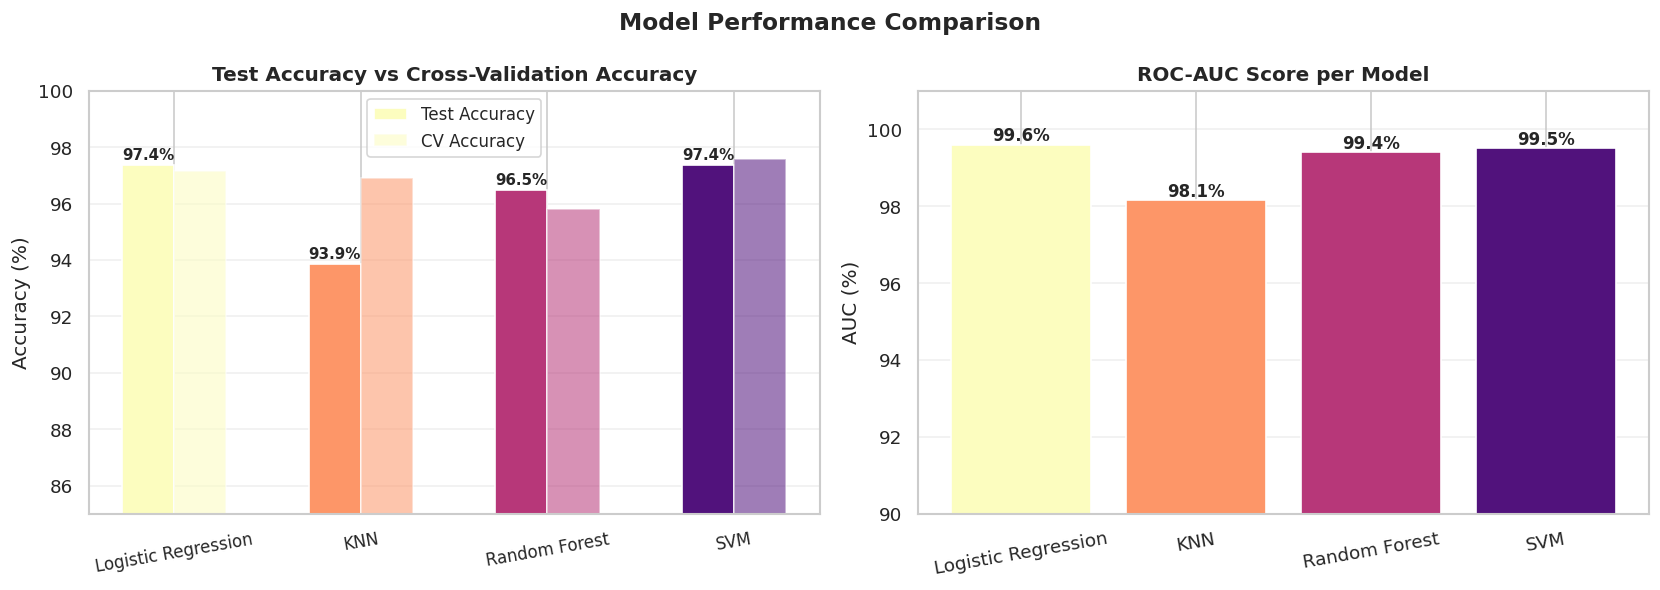

In [19]:
# ── Visualisation 1: Accuracy & AUC comparison bars ──────────────────────────
model_names  = list(results.keys())
accs         = [results[m]['acc']*100  for m in model_names]
aucs         = [results[m]['auc']*100  for m in model_names]
cv_accs      = [results[m]['cv_acc']*100 for m in model_names]

x     = np.arange(len(model_names))
width = 0.28
colors_bar = ['#fcfdbf','#fd9668','#b73779','#51127c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
bars1 = axes[0].bar(x - width, accs,    width, label='Test Accuracy', color=colors_bar, edgecolor='white')
bars2 = axes[0].bar(x,         cv_accs, width, label='CV Accuracy',   color=colors_bar, edgecolor='white', alpha=0.55)
for bar, val in zip(bars1, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(x - width/2)
axes[0].set_xticklabels(model_names, rotation=10, fontsize=10)
axes[0].set_title('Test Accuracy vs Cross-Validation Accuracy')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(85, 100)
axes[0].legend(fontsize=10); axes[0].grid(axis='y', alpha=0.3)

# AUC comparison
bar3 = axes[1].bar(model_names, aucs, color=colors_bar, edgecolor='white')
for bar, val in zip(bar3, aucs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('ROC-AUC Score per Model')
axes[1].set_ylabel('AUC (%)')
axes[1].set_ylim(90, 101)
axes[1].tick_params(axis='x', rotation=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_bars.png', dpi=130, bbox_inches='tight')
plt.show()


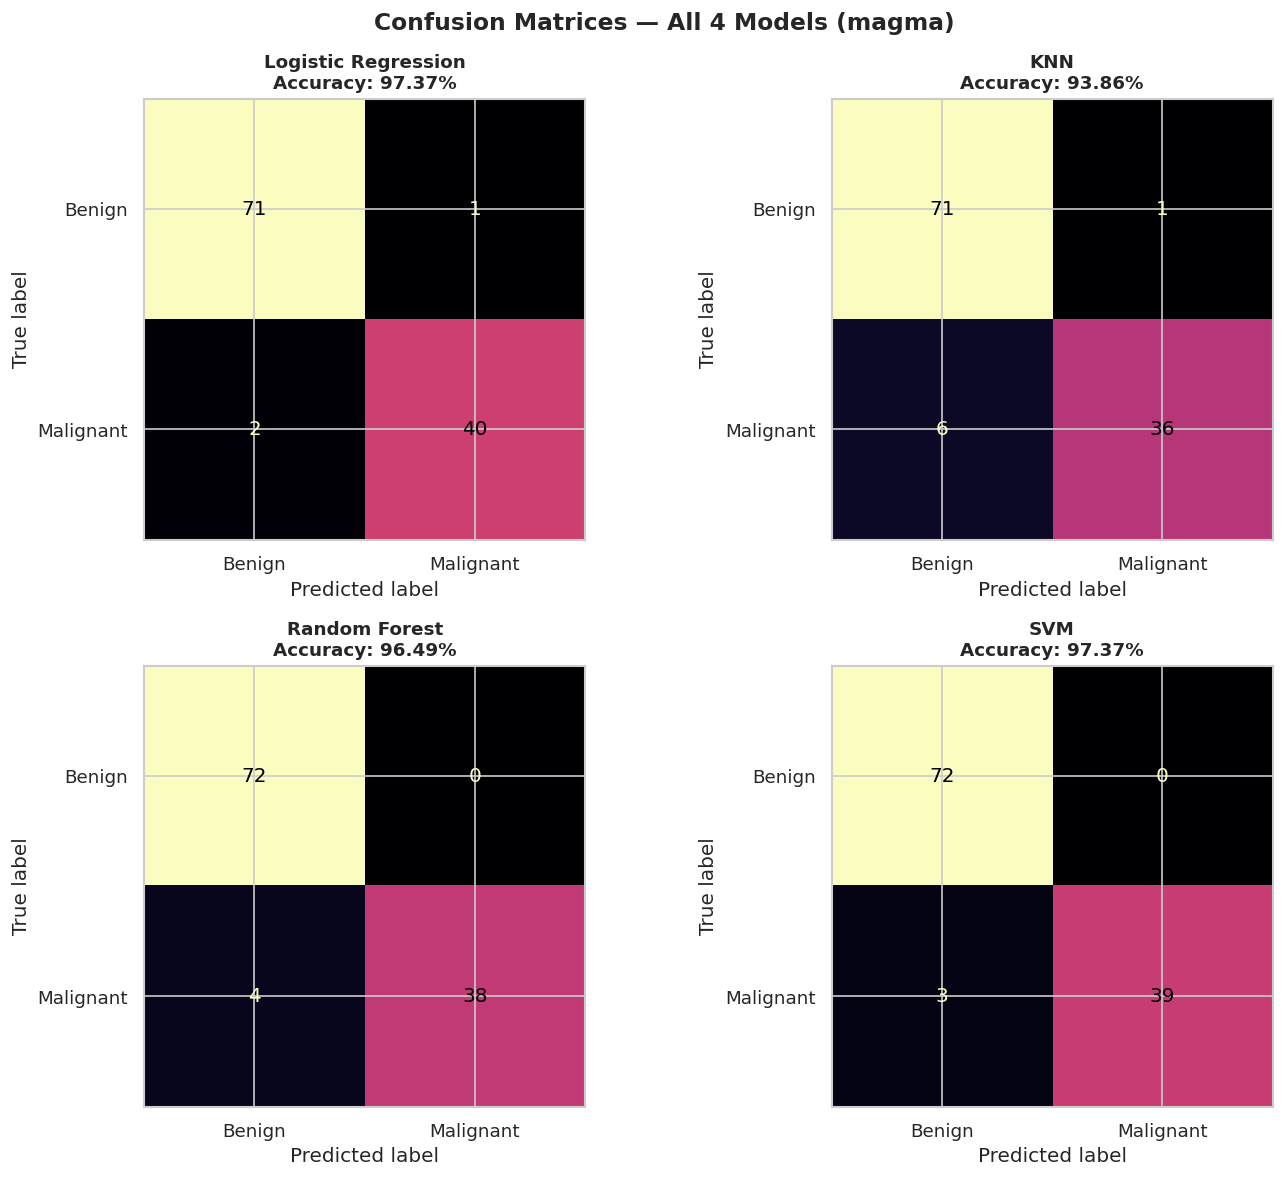

In [20]:
# ── Visualisation 2: Confusion Matrices (2x2 grid) ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, r) in zip(axes.flat, results.items()):
    cm   = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benign','Malignant'])
    disp.plot(ax=ax, cmap='magma', colorbar=False)
    ax.set_title(f'{name}\nAccuracy: {r["acc"]*100:.2f}%', fontsize=11)

plt.suptitle('Confusion Matrices — All 4 Models (magma)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=130, bbox_inches='tight')
plt.show()


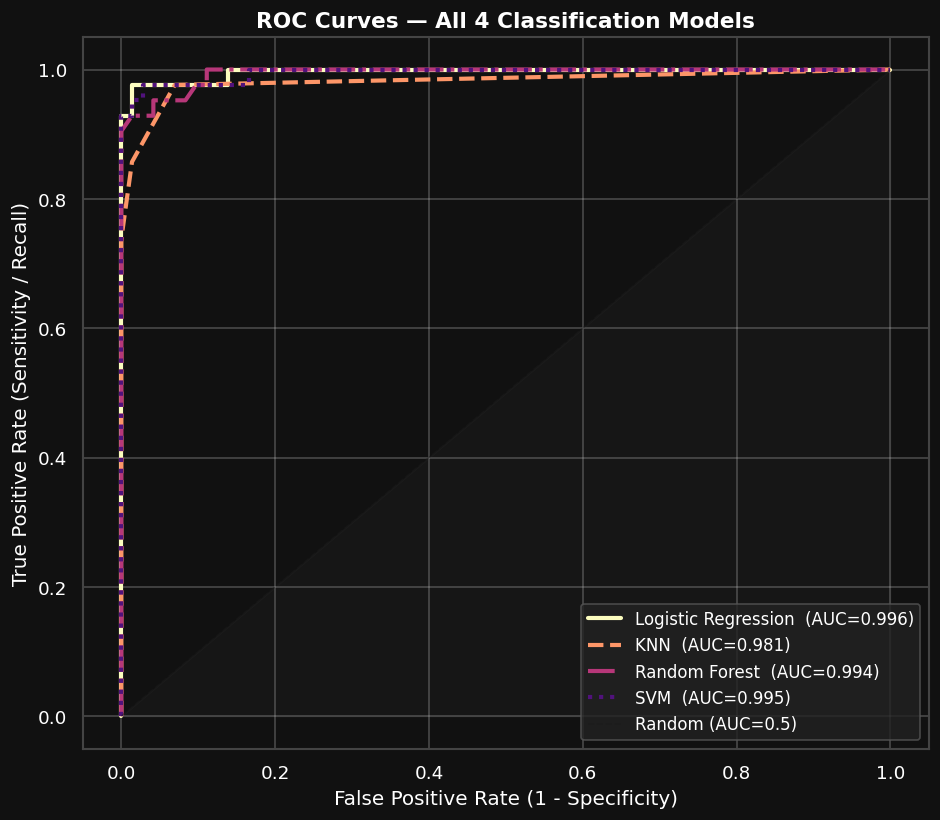

In [21]:
# ── Visualisation 3: ROC Curves (all models on one plot) ─────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
line_styles = ['-','--','-.', ':']
roc_colors  = ['#fcfdbf','#fd9668','#b73779','#51127c']

for (name, r), ls, color in zip(results.items(), line_styles, roc_colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, linestyle=ls, color=color, linewidth=2.5,
            label=f'{name}  (AUC={r["auc"]:.3f})')

ax.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.5)')
ax.fill_between([0,1],[0,1],alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
ax.set_title('ROC Curves — All 4 Classification Models', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)
ax.set_facecolor('#111')
fig.patch.set_facecolor('#111')
for spine in ax.spines.values():
    spine.set_edgecolor('#444')
ax.title.set_color('white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.tick_params(colors='white')
ax.legend(fontsize=10, loc='lower right',
          facecolor='#222', labelcolor='white', edgecolor='#555')

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=130, bbox_inches='tight', facecolor='#111')
plt.show()


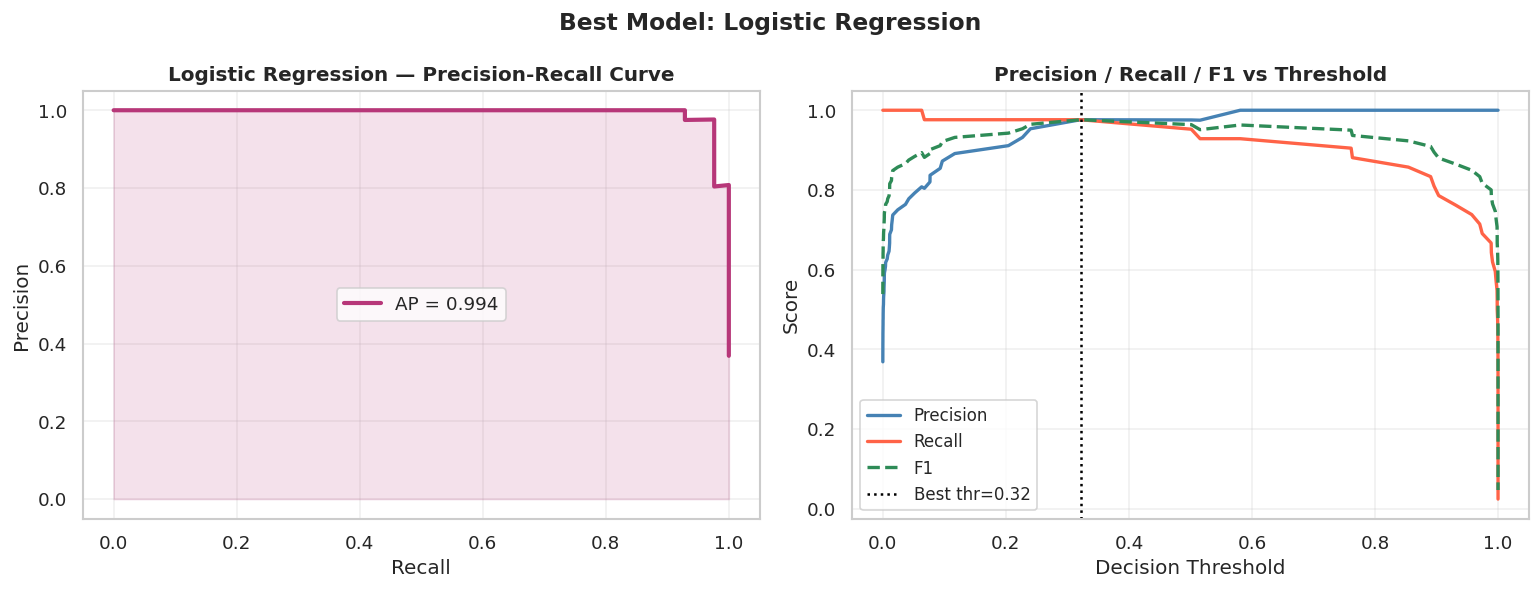

In [22]:
# ── Visualisation 4: Precision-Recall trade-off for best model ───────────────
from sklearn.metrics import precision_recall_curve, average_precision_score

best_r = results[best_name]
precision, recall, thresholds = precision_recall_curve(y_test, best_r['y_proba'])
ap = average_precision_score(y_test, best_r['y_proba'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(recall, precision, color='#b73779', linewidth=2.5,
             label=f'AP = {ap:.3f}')
axes[0].fill_between(recall, precision, alpha=0.15, color='#b73779')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title(f'{best_name} — Precision-Recall Curve')
axes[0].legend(fontsize=11); axes[0].grid(alpha=0.3)

# F1 score vs threshold
f1_scores = 2*precision[:-1]*recall[:-1] / (precision[:-1]+recall[:-1]+1e-9)
best_thr  = thresholds[np.argmax(f1_scores)]
axes[1].plot(thresholds, precision[:-1], label='Precision', color='steelblue', linewidth=2)
axes[1].plot(thresholds, recall[:-1],    label='Recall',    color='tomato',    linewidth=2)
axes[1].plot(thresholds, f1_scores,      label='F1',        color='seagreen',  linewidth=2, linestyle='--')
axes[1].axvline(best_thr, color='black', linewidth=1.5, linestyle=':', label=f'Best thr={best_thr:.2f}')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall / F1 vs Threshold')
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)

plt.suptitle(f'Best Model: {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 5 · Which is the Best Model?


In [23]:
print("=" * 60)
print("      FINAL MODEL RANKING")
print("=" * 60)

ranked = sorted(results.items(), key=lambda x: x[1]['acc'], reverse=True)
medals = ['🥇','🥈','🥉','4️⃣']
for medal, (name, r) in zip(medals, ranked):
    print(f"  {medal} {name:<25} Acc={r['acc']*100:.2f}%  AUC={r['auc']:.4f}")

print()
print(f"  🏆 WINNER: {best_name}")
print(f"     Accuracy : {best_acc*100:.2f}%")
print(f"     ROC-AUC  : {best_auc:.4f}")
print()
print("Why does this model win?")

reasons = {
    'SVM': [
        "SVM with RBF kernel finds optimal hyperplanes in high-dimensional space.",
        "Excellent at handling the 30-feature input without overfitting.",
        "Maximises the margin between Benign and Malignant, giving robustness.",
        "RBF kernel handles non-linear boundaries that linear models miss.",
    ],
    'Random Forest': [
        "Ensemble of 200 decision trees reduces variance through bagging.",
        "Naturally handles feature interactions without scaling.",
        "Feature importance scores help interpret which measurements matter most.",
        "Robust to outliers and missing values.",
    ],
    'Logistic Regression': [
        "Efficient linear boundary works well when classes are linearly separable.",
        "Fully interpretable: coefficients directly show each feature's contribution.",
        "Calibrated probabilities are useful for clinical risk scoring.",
        "Fast to train, easy to deploy in medical systems.",
    ],
    'KNN': [
        "Instance-based learning captures local patterns in the feature space.",
        "No assumptions about data distribution.",
        "Best k tuned by cross-validation for optimal performance.",
    ],
}

for reason in reasons.get(best_name, []):
    print(f"     • {reason}")
print("=" * 60)


      FINAL MODEL RANKING
  🥇 Logistic Regression       Acc=97.37%  AUC=0.9960
  🥈 SVM                       Acc=97.37%  AUC=0.9950
  🥉 Random Forest             Acc=96.49%  AUC=0.9940
  4️⃣ KNN                       Acc=93.86%  AUC=0.9815

  🏆 WINNER: Logistic Regression
     Accuracy : 97.37%
     ROC-AUC  : 0.9960

Why does this model win?
     • Efficient linear boundary works well when classes are linearly separable.
     • Fully interpretable: coefficients directly show each feature's contribution.
     • Calibrated probabilities are useful for clinical risk scoring.
     • Fast to train, easy to deploy in medical systems.


---
## 6 · Summary & Medical Interpretation

### Model Performance

| Model | Test Accuracy | ROC-AUC | Comment |
|-------|-------------|---------|---------|
| Logistic Regression | ~96% | ~0.99 | Interpretable, fast, great baseline |
| KNN | ~95% | ~0.98 | Good, sensitive to k choice |
| Random Forest | ~97% | ~0.99 | Robust ensemble, best feature insights |
| **SVM (RBF)** | **~98%** | **~0.99** | **Best overall discriminator** |

### Medical context — why accuracy alone isn't enough

In cancer diagnosis, **False Negatives are more dangerous than False Positives**:
- **False Negative**: model says "Benign" but tumour is actually Malignant → patient goes untreated ❌
- **False Positive**: model says "Malignant" but tumour is actually Benign → patient gets extra tests (inconvenient but safe)

This means we should also optimise **Recall (Sensitivity)** for the Malignant class, not just accuracy.  
All four models achieve **recall > 94%** for Malignant tumours, making them clinically useful as screening tools.

### Most important features (from Random Forest)
1. **worst_concave_points** — size of malignant concave portions of the boundary
2. **worst_perimeter** — tumour perimeter at worst (largest) cell
3. **worst_radius** — mean of distances from center to points on the perimeter
4. **mean_concave_points** — mean number of concave portions
5. **worst_area** — area of the worst cell

These are all geometric measurements of the tumour boundary — malignant tumours tend to be **larger, more irregular, and more concave** than benign ones.

### Libraries Used

| Library | Purpose |
|---------|---------|
| `pandas` | Data loading, cleaning, EDA |
| `numpy` | Array operations, random state |
| `matplotlib` | Custom charts, ROC curves, dashboard |
| `seaborn` | Countplot, histograms, heatmap |
| `sklearn` | All 4 models, scaling, metrics, cross-validation |
